<a href="https://www.kaggle.com/code/lalit7881/global-remittance-analytics-eda?scriptVersionId=317988089" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/rpw_corridor_costs.csv
/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/imf_indicators.csv
/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/worldbank_indicators.csv
/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/un_sdg_indicators.csv


## Loading dataset

In [2]:


# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# ======================
# 2. LOAD DATASETS
# ======================

rpw = pd.read_csv(
    "/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/rpw_corridor_costs.csv"
)

imf = pd.read_csv(
    "/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/imf_indicators.csv"
)

wb = pd.read_csv(
    "/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/worldbank_indicators.csv"
)

sdg = pd.read_csv(
    "/kaggle/input/datasets/darwish1337/global-remittances-and-migration-dataset-2000-2023/un_sdg_indicators.csv"
)

# ======================
# 3. BASIC INFORMATION
# ======================

print("="*50)
print("RPW DATASET")
print("="*50)

print(rpw.head())
print(rpw.shape)
print(rpw.columns)
print(rpw.info())

print("="*50)
print("IMF DATASET")
print("="*50)

print(imf.head())
print(imf.shape)
print(imf.columns)
print(imf.info())

print("="*50)
print("WORLD BANK DATASET")
print("="*50)

print(wb.head())
print(wb.shape)
print(wb.columns)
print(wb.info())

print("="*50)
print("SDG DATASET")
print("="*50)

print(sdg.head())
print(sdg.shape)
print(sdg.columns)
print(sdg.info())

# ======================
# 4. CHECK NULL VALUES
# ======================

print("="*50)
print("NULL VALUES")
print("="*50)

print("RPW NULL VALUES")
print(rpw.isnull().sum())

print("\nIMF NULL VALUES")
print(imf.isnull().sum())

print("\nWORLD BANK NULL VALUES")
print(wb.isnull().sum())

print("\nSDG NULL VALUES")
print(sdg.isnull().sum())

# ======================
# 5. CHECK DUPLICATES
# ======================

print("="*50)
print("DUPLICATES")
print("="*50)

print("RPW Duplicates:", rpw.duplicated().sum())
print("IMF Duplicates:", imf.duplicated().sum())
print("WB Duplicates:", wb.duplicated().sum())
print("SDG Duplicates:", sdg.duplicated().sum())

# Remove duplicates
rpw = rpw.drop_duplicates()
imf = imf.drop_duplicates()
wb = wb.drop_duplicates()
sdg = sdg.drop_duplicates()

# ======================
# 6. DESCRIPTIVE STATISTICS
# ======================

print("="*50)
print("DESCRIPTIVE STATISTICS")
print("="*50)

print(rpw.describe(include='all'))
print(imf.describe(include='all'))
print(wb.describe(include='all'))
print(sdg.describe(include='all'))

# ======================
# 7. CHECK DATA TYPES
# ======================

print("="*50)
print("DATA TYPES")
print("="*50)

print(rpw.dtypes)
print(imf.dtypes)
print(wb.dtypes)
print(sdg.dtypes)

# ======================
# 8. CONVERT DATE/YEAR COLUMNS
# ======================

# Automatically detect possible year/date columns

datasets = {
    "rpw": rpw,
    "imf": imf,
    "wb": wb,
    "sdg": sdg
}

for name, df in datasets.items():

    for col in df.columns:

        if 'year' in col.lower():
            try:
                df[col] = pd.to_numeric(df[col], errors='coerce')
            except:
                pass

print("Year columns converted.")

# ======================
# 9. HANDLE MISSING VALUES
# ======================

# Numeric columns -> median
# Categorical columns -> mode

for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns
    categorical_cols = df.select_dtypes(exclude=np.number).columns

    # Fill numeric nulls
    for col in numeric_cols:
        df[col] = df[col].fillna(df[col].median())

    # Fill categorical nulls
    for col in categorical_cols:
        if df[col].mode().shape[0] > 0:
            df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values handled.")

# ======================
# 10. CHECK UNIQUE VALUES
# ======================

print("="*50)
print("UNIQUE VALUES")
print("="*50)

for name, df in datasets.items():

    print(f"\n{name.upper()} DATASET")

    for col in df.columns[:10]:

        print(f"{col} : {df[col].nunique()}")

# ======================
# 11. CHECK CORRELATION
# ======================

print("="*50)
print("CORRELATION")
print("="*50)

for name, df in datasets.items():

    numeric_df = df.select_dtypes(include=np.number)

    if numeric_df.shape[1] > 1:

        corr = numeric_df.corr()

        print(f"\n{name.upper()} CORRELATION MATRIX")
        print(corr)

# ======================
# 12. SORTING
# ======================

print("="*50)
print("SORTING")
print("="*50)

for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    if len(numeric_cols) > 0:

        sorted_df = df.sort_values(by=numeric_cols[0], ascending=False)

        print(f"\n{name.upper()} SORTED DATA")
        print(sorted_df.head())

# ======================
# 13. FILTERING
# ======================

print("="*50)
print("FILTERING")
print("="*50)

for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    if len(numeric_cols) > 0:

        filtered_df = df[df[numeric_cols[0]] > df[numeric_cols[0]].mean()]

        print(f"\n{name.upper()} FILTERED DATA")
        print(filtered_df.head())

# ======================
# 14. GROUPBY OPERATIONS
# ======================

print("="*50)
print("GROUPBY")
print("="*50)

for name, df in datasets.items():

    categorical_cols = df.select_dtypes(exclude=np.number).columns
    numeric_cols = df.select_dtypes(include=np.number).columns

    if len(categorical_cols) > 0 and len(numeric_cols) > 0:

        grouped = df.groupby(categorical_cols[0])[numeric_cols[0]].mean()

        print(f"\n{name.upper()} GROUPBY")
        print(grouped.head())

# ======================
# 15. VALUE COUNTS
# ======================

print("="*50)
print("VALUE COUNTS")
print("="*50)

for name, df in datasets.items():

    categorical_cols = df.select_dtypes(exclude=np.number).columns

    if len(categorical_cols) > 0:

        print(f"\n{name.upper()} VALUE COUNTS")

        print(df[categorical_cols[0]].value_counts().head())

# ======================
# 16. CREATE NEW FEATURES
# ======================

print("="*50)
print("FEATURE ENGINEERING")
print("="*50)

for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    if len(numeric_cols) >= 2:

        df['sum_feature'] = df[numeric_cols[0]] + df[numeric_cols[1]]

        df['mean_feature'] = (
            df[numeric_cols].mean(axis=1)
        )

print("New features created.")

# ======================
# 17. OUTLIER DETECTION
# ======================

print("="*50)
print("OUTLIER DETECTION")
print("="*50)

for name, df in datasets.items():

    numeric_cols = df.select_dtypes(include=np.number).columns

    for col in numeric_cols[:3]:

        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers = df[
            (df[col] < lower) |
            (df[col] > upper)
        ]

        print(f"{name.upper()} - {col} Outliers:", outliers.shape[0])

# ======================
# 18. EXPORT CLEAN DATA
# ======================

rpw.to_csv("clean_rpw.csv", index=False)
imf.to_csv("clean_imf.csv", index=False)
wb.to_csv("clean_worldbank.csv", index=False)
sdg.to_csv("clean_sdg.csv", index=False)

print("="*50)
print("CLEANED FILES SAVED")
print("="*50)

# ======================
# 19. FINAL SHAPES
# ======================

print("="*50)
print("FINAL DATASET SHAPES")
print("="*50)

print("RPW:", rpw.shape)
print("IMF:", imf.shape)
print("WORLD BANK:", wb.shape)
print("SDG:", sdg.shape)

# ======================
# 20. MEMORY USAGE
# ======================

print("="*50)
print("MEMORY USAGE")
print("="*50)

for name, df in datasets.items():

    memory = df.memory_usage(deep=True).sum() / 1024**2

    print(f"{name.upper()} Memory Usage: {memory:.2f} MB")

print("="*50)
print("PANDAS ANALYSIS COMPLETED")
print("="*50)

RPW DATASET
  receiving_country  period  avg_total_cost_pct     source_engine
0                AF    2023            9.024333  worldbank_api_v2
1                AF    2022           10.182500  worldbank_api_v2
2                AF    2021            9.449582  worldbank_api_v2
3                AF    2020            9.029006  worldbank_api_v2
4                AF    2019            8.168026  worldbank_api_v2
(96, 4)
Index(['receiving_country', 'period', 'avg_total_cost_pct', 'source_engine'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   receiving_country   96 non-null     object 
 1   period              96 non-null     int64  
 2   avg_total_cost_pct  96 non-null     float64
 3   source_engine       96 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 3.1+ KB
None
IMF DATASET
  country_code 

In [3]:
print(df.columns.tolist())

['country_code', 'country_name', 'year', 'remittance_cost_pct', 'source_engine', 'sum_feature', 'mean_feature']


## EDA

COLUMN NAMES
['country_code', 'country_name', 'year', 'remittance_cost_pct', 'source_engine', 'sum_feature', 'mean_feature']
DATASET SHAPE
(818, 7)
FIRST 5 ROWS
   country_code country_name  year  remittance_cost_pct source_engine  \
0             4  Afghanistan  2017                 9.88    un_sdg_api   
1             4  Afghanistan  2018                 9.23    un_sdg_api   
2             4  Afghanistan  2019                 9.72    un_sdg_api   
3             4  Afghanistan  2020                 9.89    un_sdg_api   
4             4  Afghanistan  2021                 8.39    un_sdg_api   

   sum_feature  mean_feature  
0         2021    676.960000  
1         2022    677.076667  
2         2023    677.573333  
3         2024    677.963333  
4         2025    677.796667  
DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 818 entries, 0 to 817
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----

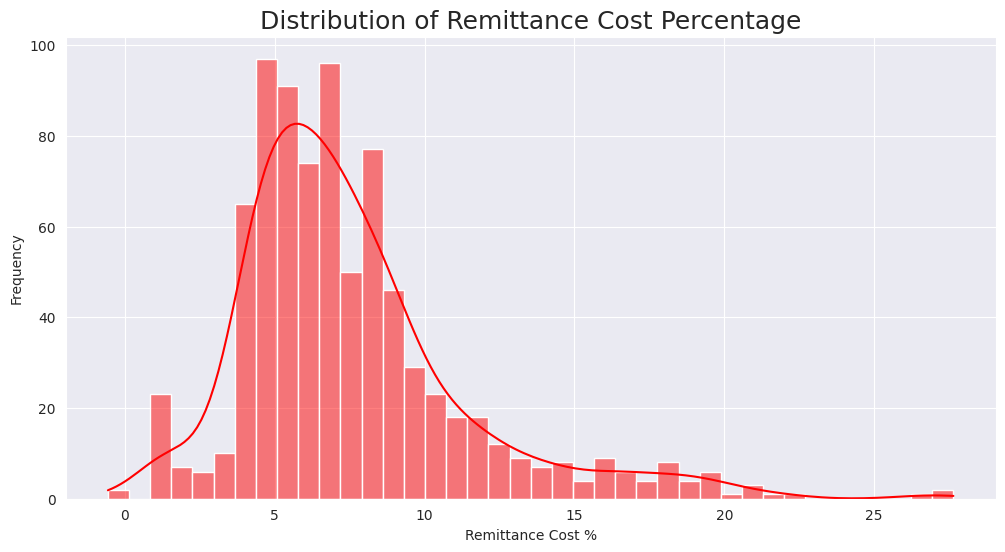

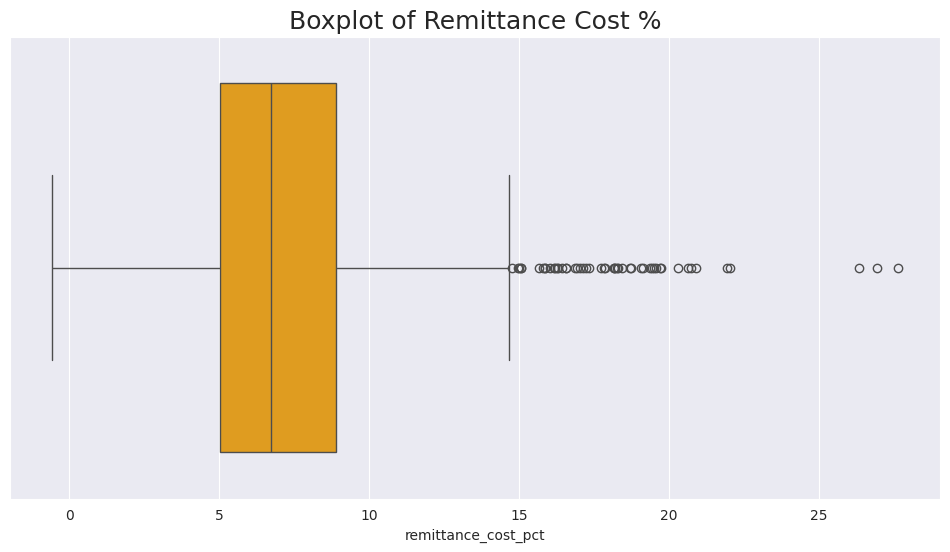

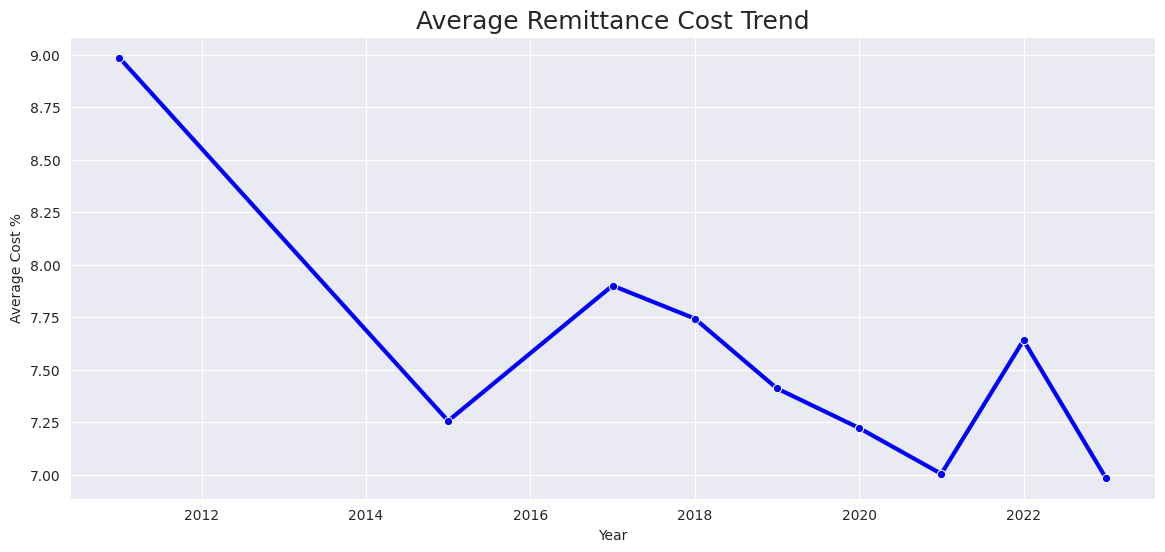

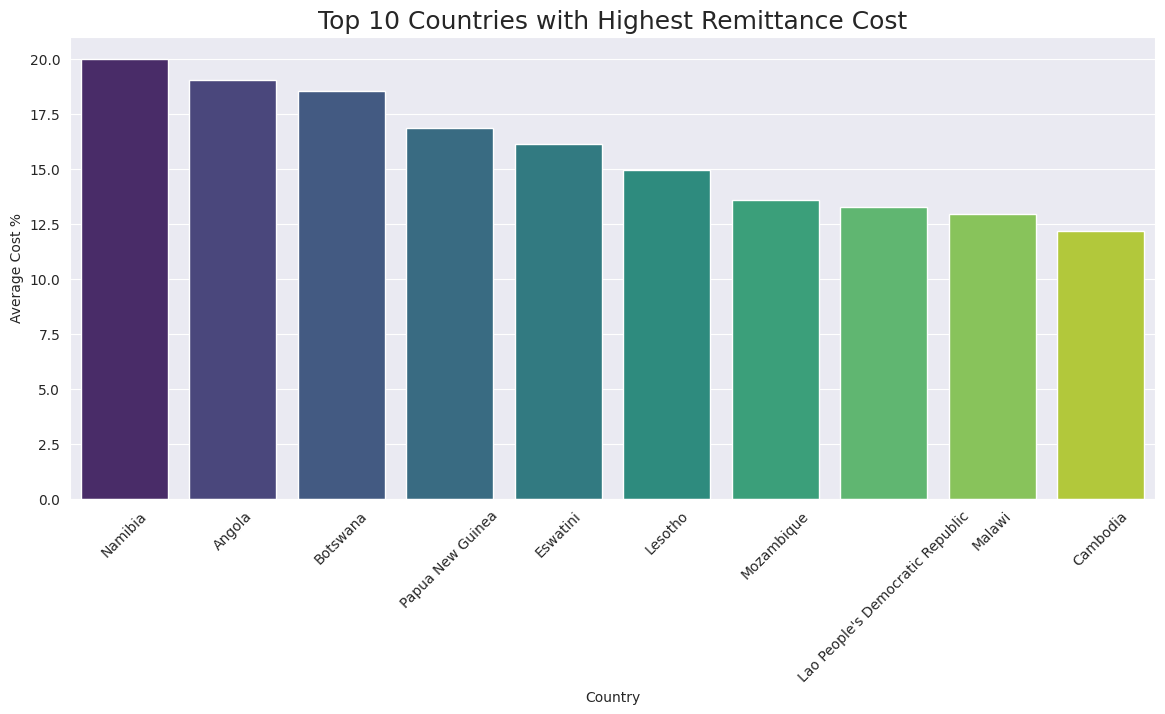

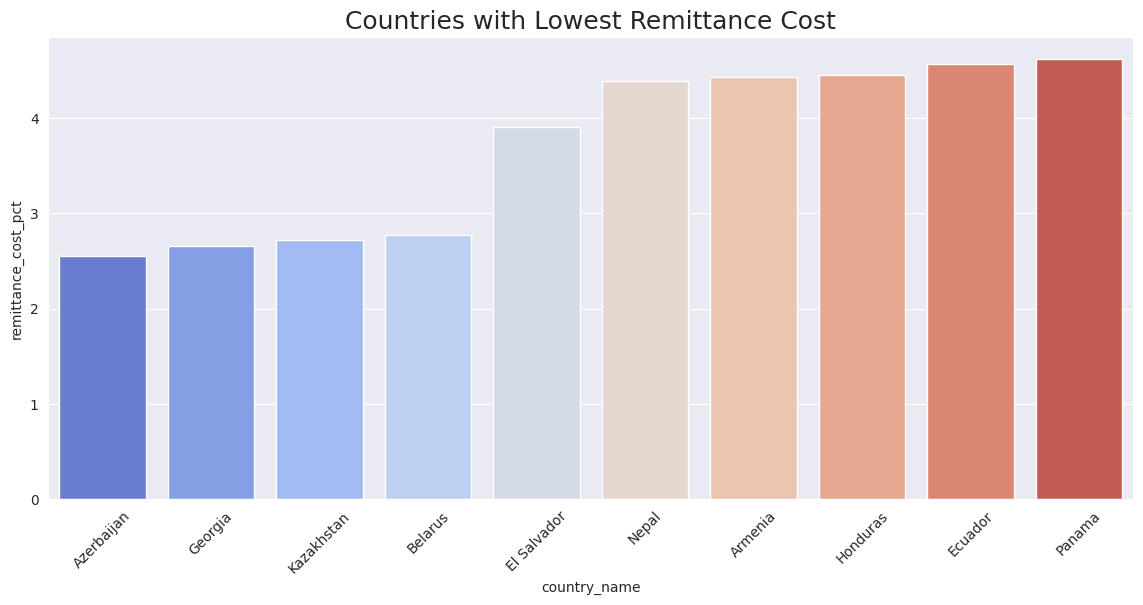

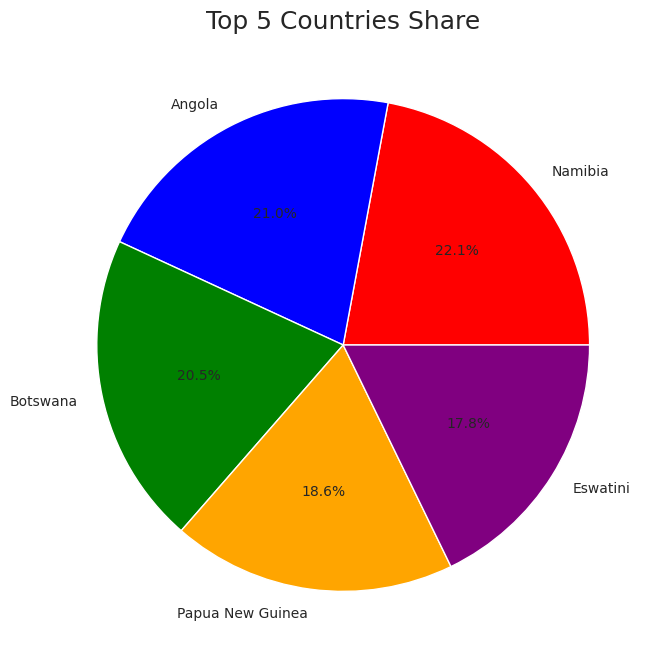

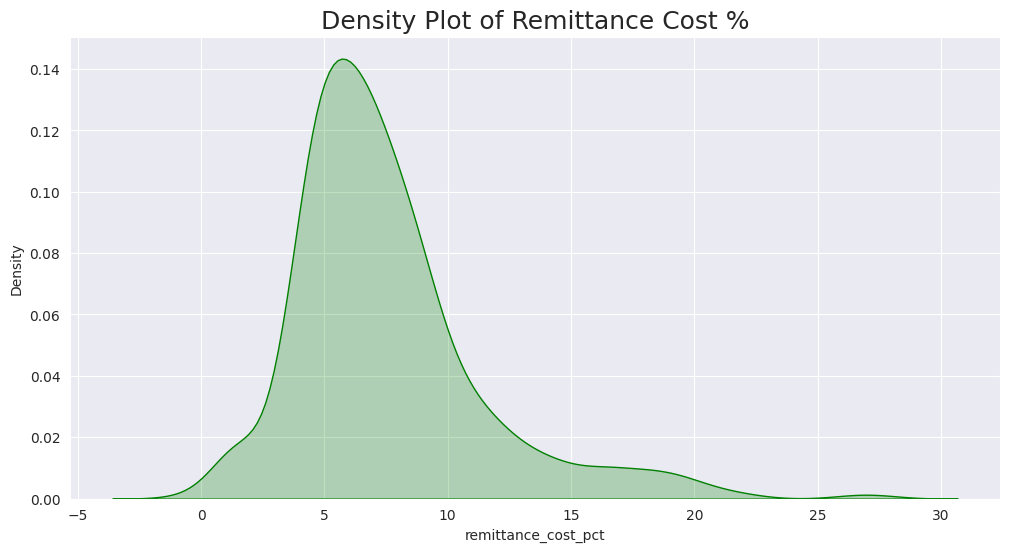

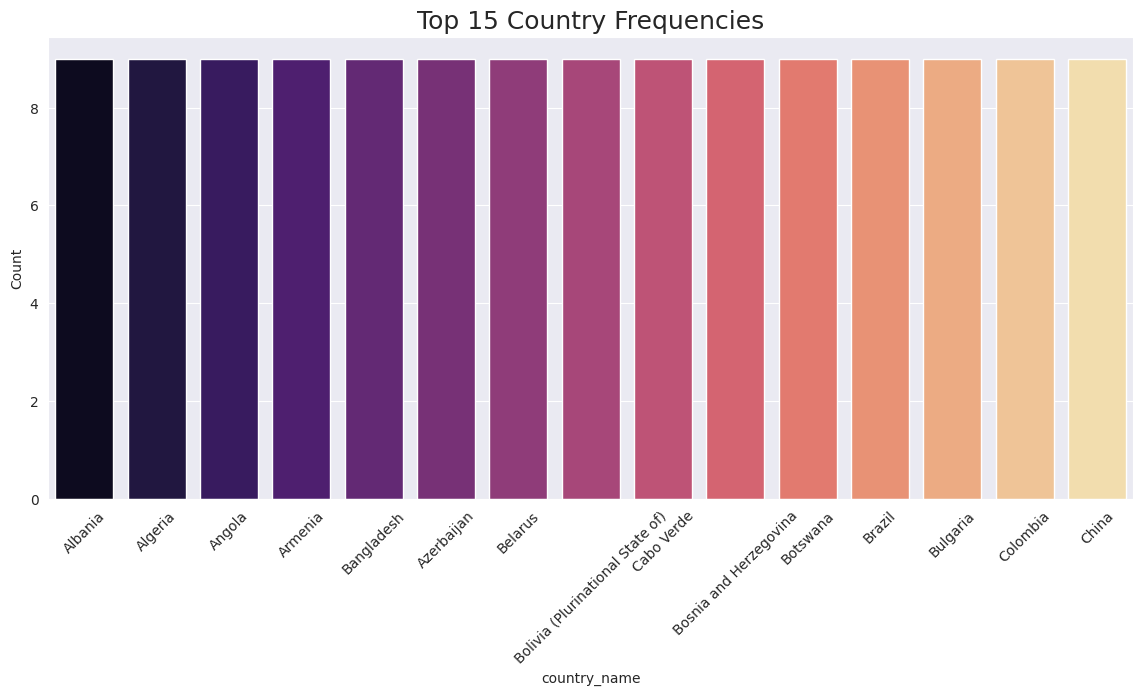

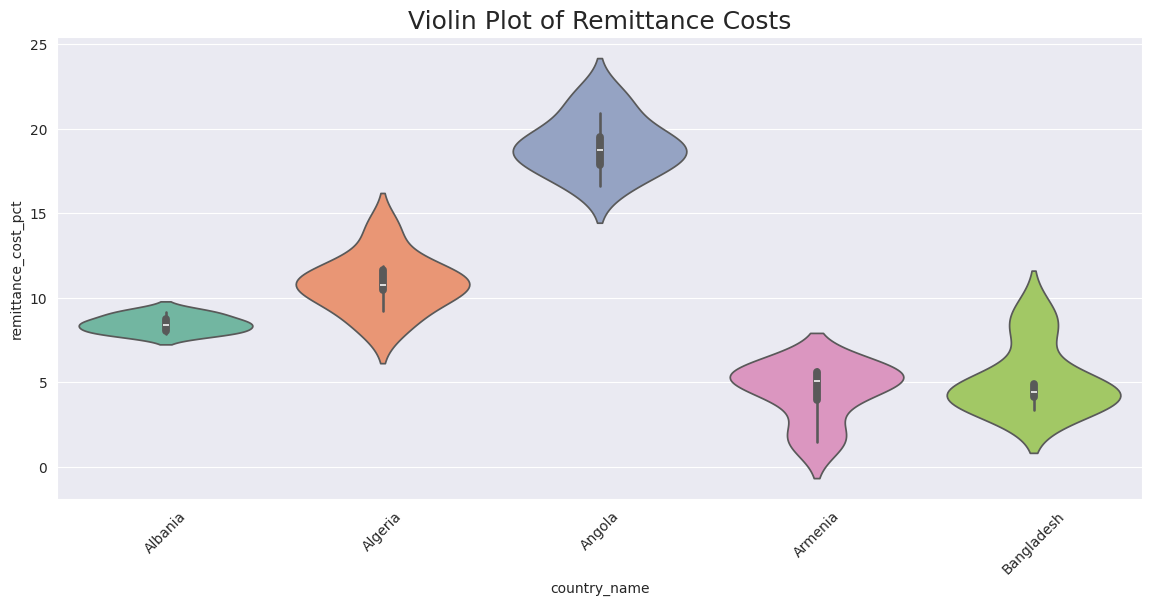

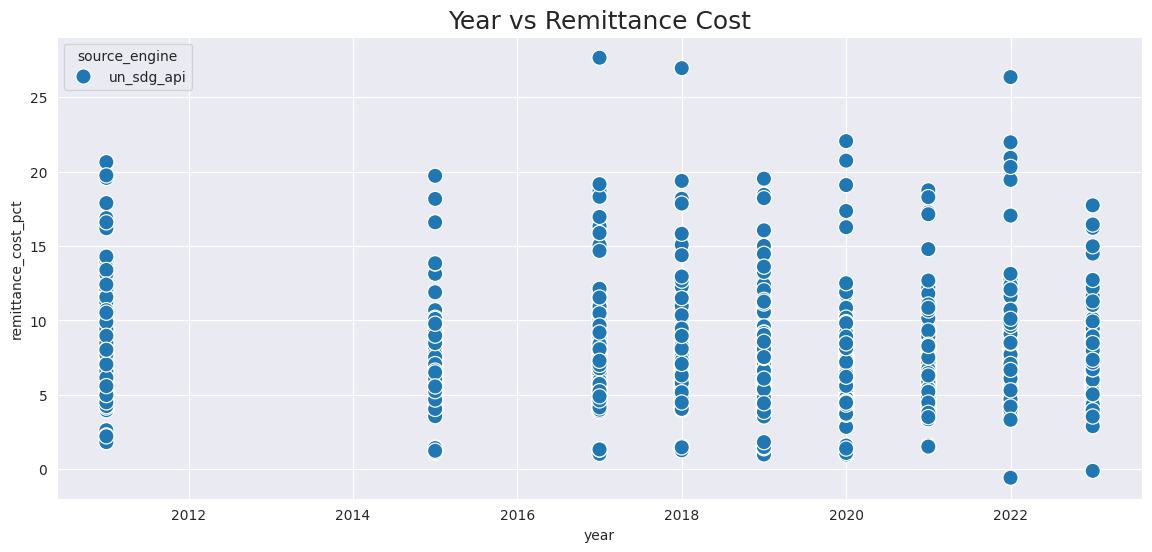

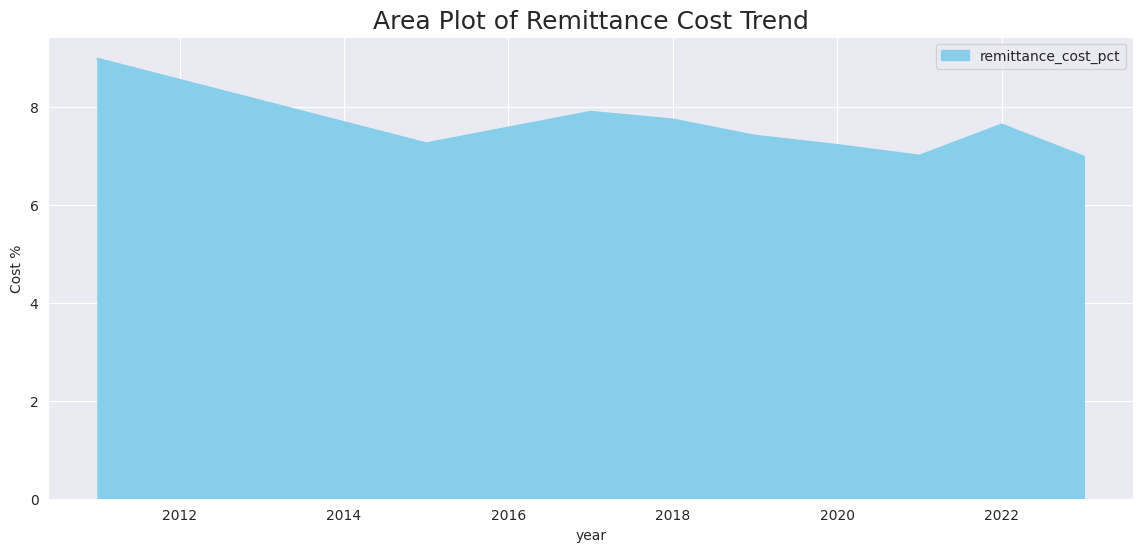

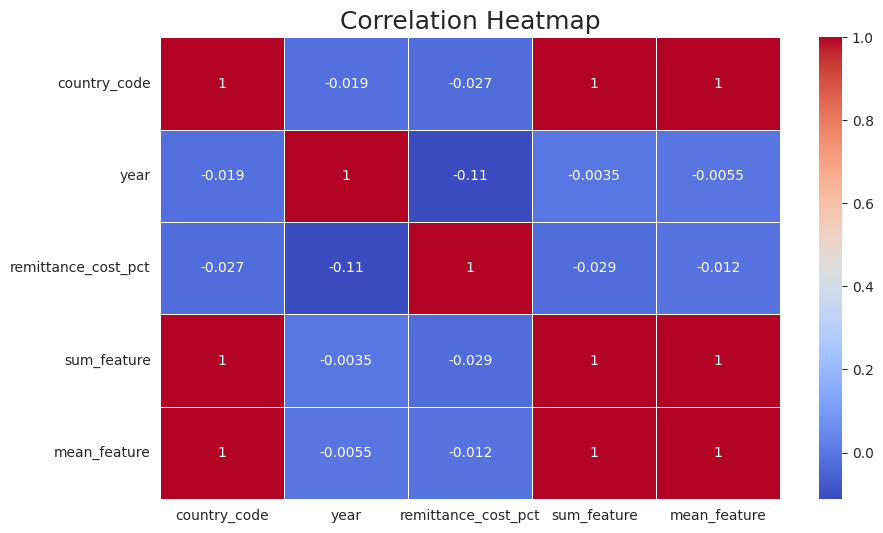

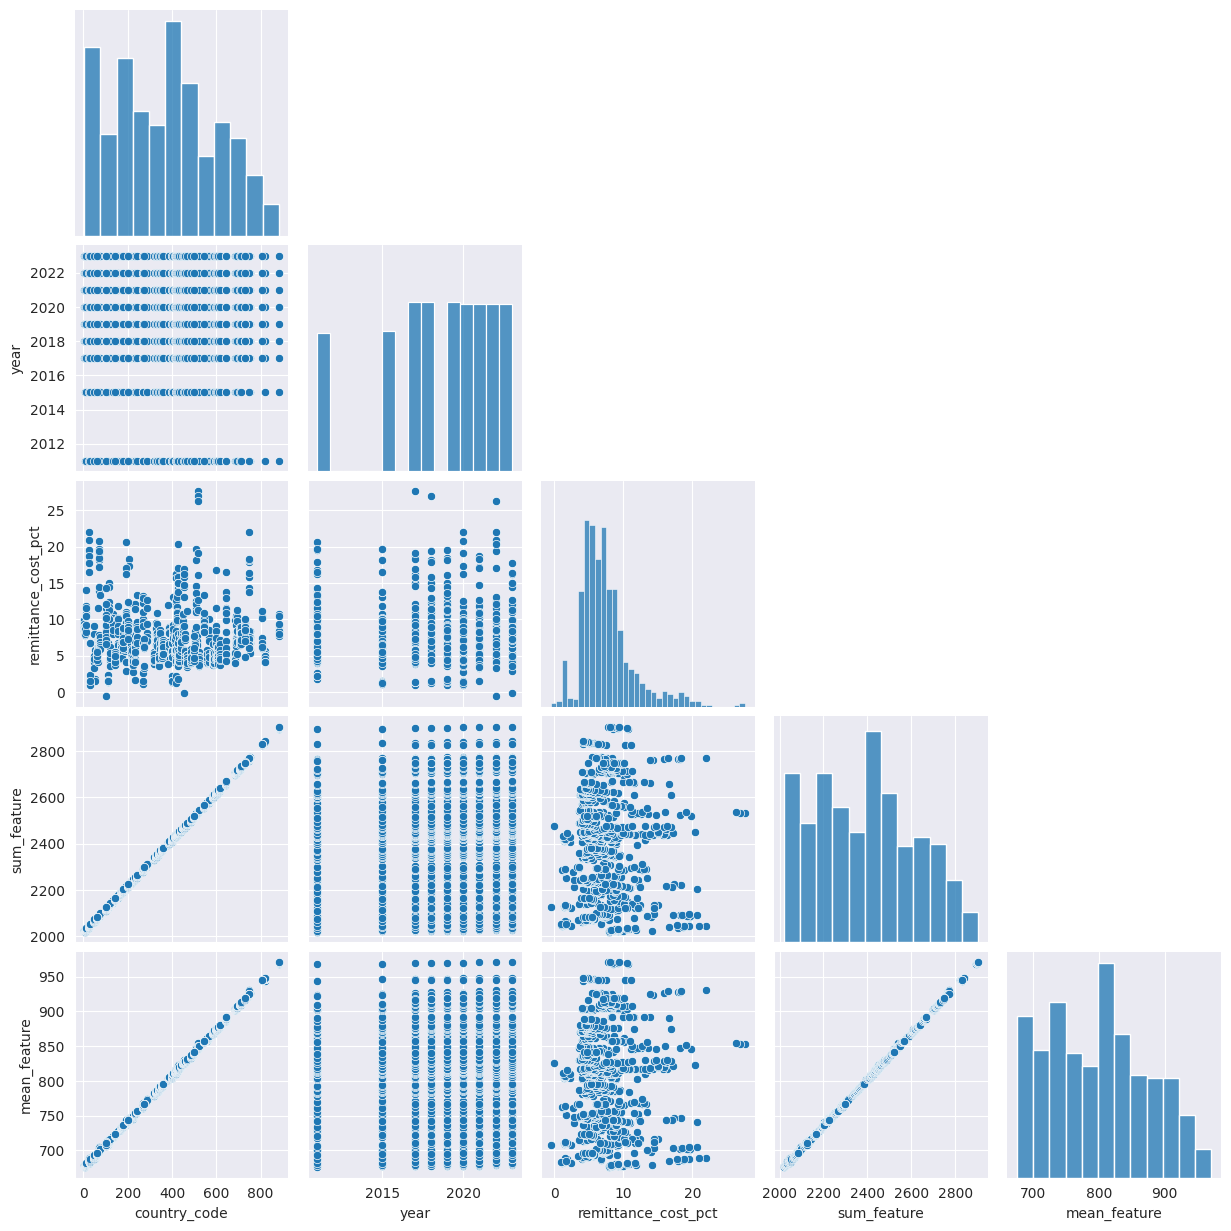

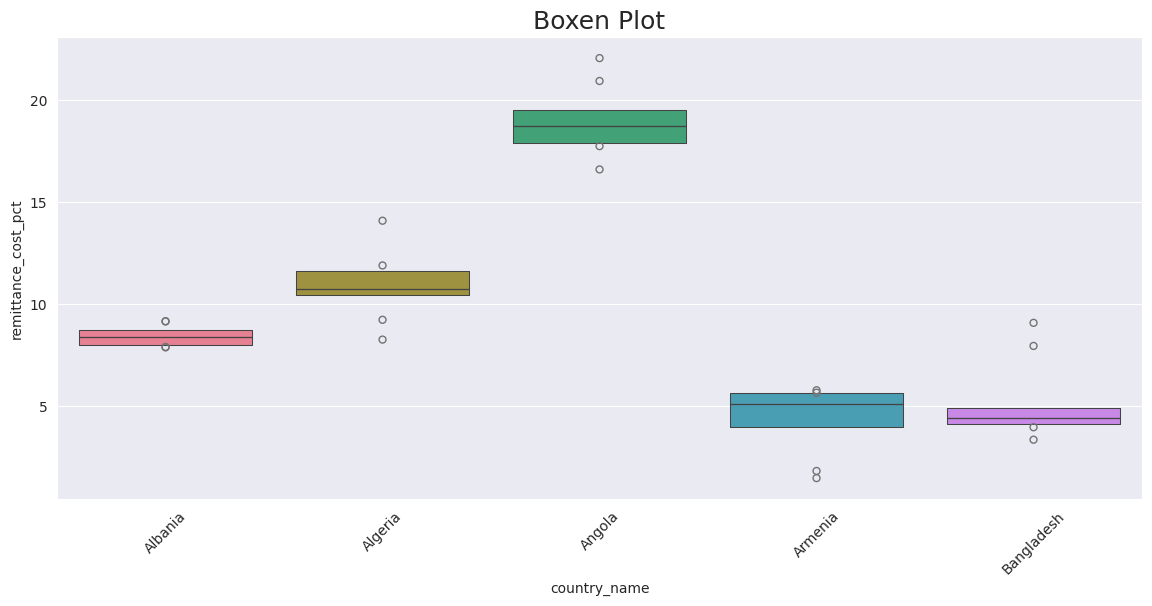

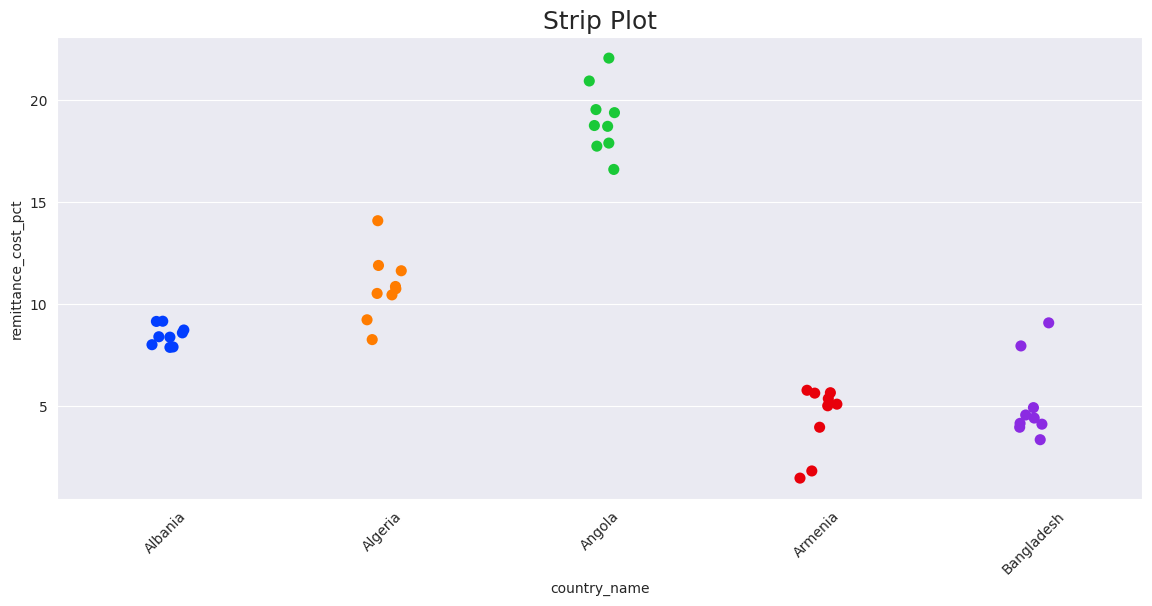

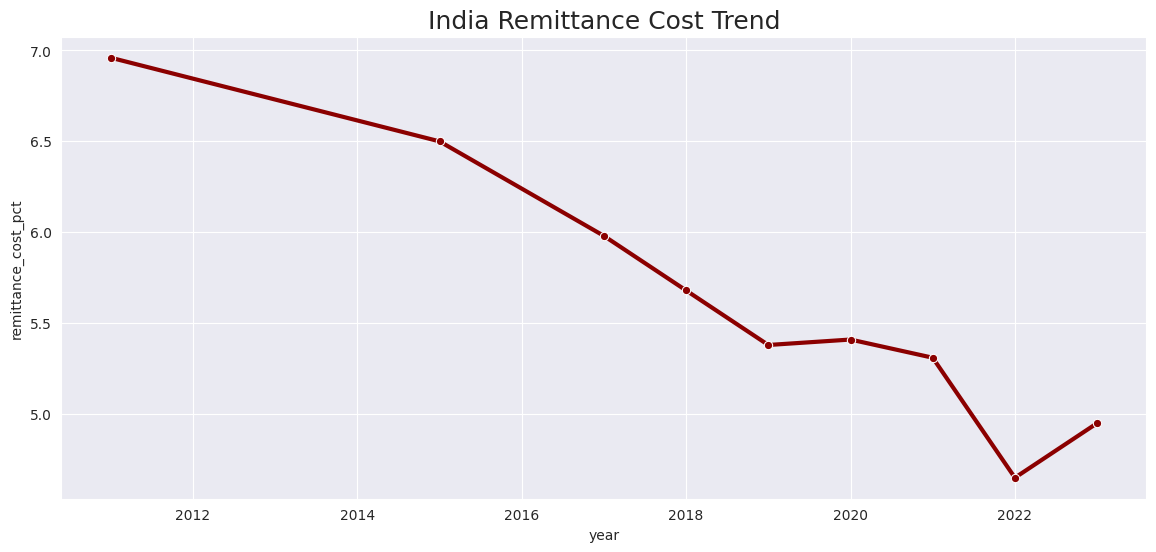

VISUALIZATION COMPLETED SUCCESSFULLY


In [4]:

import plotly.express as px
import plotly.graph_objects as go


pd.set_option('display.max_columns', None)

sns.set_style("darkgrid")

plt.rcParams['figure.figsize'] = (12,6)


df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns.tolist())

# ======================
# 5. BASIC INFORMATION
# ======================

print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("="*60)
print("FIRST 5 ROWS")
print("="*60)

print(df.head())

print("="*60)
print("DATASET INFO")
print("="*60)

print(df.info())

# ======================
# 6. HANDLE MISSING VALUES
# ======================

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    
    df[col] = df[col].fillna(df[col].median())

categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    
    df[col] = df[col].fillna(df[col].mode()[0])

print("="*60)
print("MISSING VALUES HANDLED")
print("="*60)

# ======================
# 7. DESCRIPTIVE STATISTICS
# ======================

print("="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)

print(df.describe(include='all'))

# ============================================================
# 8. HISTOGRAM
# ============================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['remittance_cost_pct'],
    bins=40,
    kde=True,
    color='red'
)

plt.title(
    "Distribution of Remittance Cost Percentage",
    fontsize=18
)

plt.xlabel("Remittance Cost %")
plt.ylabel("Frequency")

plt.show()

# ============================================================
# 9. BOXPLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.boxplot(
    x=df['remittance_cost_pct'],
    color='orange'
)

plt.title(
    "Boxplot of Remittance Cost %",
    fontsize=18
)

plt.show()

# ============================================================
# 10. YEARLY TREND
# ============================================================

yearly = (
    df.groupby('year')['remittance_cost_pct']
    .mean()
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.lineplot(
    data=yearly,
    x='year',
    y='remittance_cost_pct',
    color='blue',
    linewidth=3,
    marker='o'
)

plt.title(
    "Average Remittance Cost Trend",
    fontsize=18
)

plt.xlabel("Year")
plt.ylabel("Average Cost %")

plt.show()

# ============================================================
# 11. TOP COUNTRIES
# ============================================================

top_countries = (
    df.groupby('country_name')['remittance_cost_pct']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=top_countries,
    x='country_name',
    y='remittance_cost_pct',
    palette='viridis'
)

plt.xticks(rotation=45)

plt.title(
    "Top 10 Countries with Highest Remittance Cost",
    fontsize=18
)

plt.xlabel("Country")
plt.ylabel("Average Cost %")

plt.show()

# ============================================================
# 12. LOWEST COST COUNTRIES
# ============================================================

lowest_countries = (
    df.groupby('country_name')['remittance_cost_pct']
    .mean()
    .sort_values(ascending=True)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(14,6))

sns.barplot(
    data=lowest_countries,
    x='country_name',
    y='remittance_cost_pct',
    palette='coolwarm'
)

plt.xticks(rotation=45)

plt.title(
    "Countries with Lowest Remittance Cost",
    fontsize=18
)

plt.show()

# ============================================================
# 13. PIE CHART
# ============================================================

top5 = (
    df.groupby('country_name')['remittance_cost_pct']
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,8))

plt.pie(
    top5.values,
    labels=top5.index,
    autopct='%1.1f%%',
    colors=['red', 'blue', 'green', 'orange', 'purple']
)

plt.title(
    "Top 5 Countries Share",
    fontsize=18
)

plt.show()

# ============================================================
# 14. KDE PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.kdeplot(
    df['remittance_cost_pct'],
    fill=True,
    color='green'
)

plt.title(
    "Density Plot of Remittance Cost %",
    fontsize=18
)

plt.show()

# ============================================================
# 15. COUNT PLOT
# ============================================================

top_counts = (
    df['country_name']
    .value_counts()
    .head(15)
)

plt.figure(figsize=(14,6))

sns.barplot(
    x=top_counts.index,
    y=top_counts.values,
    palette='magma'
)

plt.xticks(rotation=45)

plt.title(
    "Top 15 Country Frequencies",
    fontsize=18
)

plt.ylabel("Count")

plt.show()

# ============================================================
# 16. VIOLIN PLOT
# ============================================================

sample_countries = df[
    df['country_name'].isin(
        df['country_name'].value_counts().head(5).index
    )
]

plt.figure(figsize=(14,6))

sns.violinplot(
    data=sample_countries,
    x='country_name',
    y='remittance_cost_pct',
    palette='Set2'
)

plt.xticks(rotation=45)

plt.title(
    "Violin Plot of Remittance Costs",
    fontsize=18
)

plt.show()

# ============================================================
# 17. SCATTER PLOT
# ============================================================

plt.figure(figsize=(14,6))

sns.scatterplot(
    data=df,
    x='year',
    y='remittance_cost_pct',
    hue='source_engine',
    palette='tab10',
    s=120
)

plt.title(
    "Year vs Remittance Cost",
    fontsize=18
)

plt.show()

# ============================================================
# 18. AREA PLOT
# ============================================================

area_df = yearly.set_index('year')

area_df.plot(
    kind='area',
    figsize=(14,6),
    color='skyblue'
)

plt.title(
    "Area Plot of Remittance Cost Trend",
    fontsize=18
)

plt.ylabel("Cost %")

plt.show()

# ============================================================
# 19. HEATMAP
# ============================================================

plt.figure(figsize=(10,6))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title(
    "Correlation Heatmap",
    fontsize=18
)

plt.show()

# ============================================================
# 20. PAIRPLOT
# ============================================================

pair_df = df.select_dtypes(include=np.number)

sns.pairplot(
    pair_df,
    corner=True
)

plt.show()

# ============================================================
# 21. BOXEN PLOT
# ============================================================

plt.figure(figsize=(14,6))

sns.boxenplot(
    data=sample_countries,
    x='country_name',
    y='remittance_cost_pct',
    palette='husl'
)

plt.xticks(rotation=45)

plt.title(
    "Boxen Plot",
    fontsize=18
)

plt.show()

# ============================================================
# 22. STRIP PLOT
# ============================================================

plt.figure(figsize=(14,6))

sns.stripplot(
    data=sample_countries,
    x='country_name',
    y='remittance_cost_pct',
    palette='bright',
    size=8
)

plt.xticks(rotation=45)

plt.title(
    "Strip Plot",
    fontsize=18
)

plt.show()

# ============================================================
# 23. INTERACTIVE LINE CHART
# ============================================================

fig = px.line(
    yearly,
    x='year',
    y='remittance_cost_pct',
    title='Interactive Remittance Cost Trend',
    color_discrete_sequence=['red']
)

fig.show()

# ============================================================
# 24. INTERACTIVE BAR CHART
# ============================================================

fig = px.bar(
    top_countries,
    x='country_name',
    y='remittance_cost_pct',
    color='remittance_cost_pct',
    color_continuous_scale='Viridis',
    title='Top Countries by Remittance Cost'
)

fig.show()

# ============================================================
# 25. CHOROPLETH MAP
# ============================================================

map_df = (
    df.groupby(
        ['country_code', 'country_name']
    )['remittance_cost_pct']
    .mean()
    .reset_index()
)

fig = px.choropleth(
    map_df,
    locations='country_code',
    color='remittance_cost_pct',
    hover_name='country_name',
    color_continuous_scale='Plasma',
    title='Global Remittance Cost Map'
)

fig.show()

# ============================================================
# 26. TREEMAP
# ============================================================

fig = px.treemap(
    top_countries,
    path=['country_name'],
    values='remittance_cost_pct',
    color='remittance_cost_pct',
    color_continuous_scale='Viridis'
)

fig.show()

# ============================================================
# 27. SUNBURST CHART
# ============================================================

fig = px.sunburst(
    df,
    path=['source_engine', 'country_name'],
    values='remittance_cost_pct',
    color='remittance_cost_pct',
    color_continuous_scale='RdBu'
)

fig.show()

# ============================================================
# 28. 3D SCATTER PLOT
# ============================================================

if 'mean_feature' in df.columns:

    fig = px.scatter_3d(
        df,
        x='year',
        y='remittance_cost_pct',
        z='mean_feature',
        color='source_engine',
        hover_name='country_name'
    )

    fig.show()

# ============================================================
# 29. COUNTRY-WISE ANALYSIS
# ============================================================

india_df = df[df['country_name'] == 'India']

if india_df.shape[0] > 0:

    plt.figure(figsize=(14,6))

    sns.lineplot(
        data=india_df,
        x='year',
        y='remittance_cost_pct',
        color='darkred',
        linewidth=3,
        marker='o'
    )

    plt.title(
        "India Remittance Cost Trend",
        fontsize=18
    )

    plt.show()

# ============================================================
# 30. SAVE CLEAN DATASET
# ============================================================

df.to_csv(
    "processed_remittance_dataset.csv",
    index=False
)

print("="*60)
print("VISUALIZATION COMPLETED SUCCESSFULLY")
print("="*60)

COLUMN NAMES
['country_code', 'country_name', 'year', 'remittance_cost_pct', 'source_engine', 'sum_feature', 'mean_feature']
DATASET SHAPE
(818, 7)
FIRST 5 ROWS
   country_code country_name  year  remittance_cost_pct source_engine  \
0             4  Afghanistan  2017                 9.88    un_sdg_api   
1             4  Afghanistan  2018                 9.23    un_sdg_api   
2             4  Afghanistan  2019                 9.72    un_sdg_api   
3             4  Afghanistan  2020                 9.89    un_sdg_api   
4             4  Afghanistan  2021                 8.39    un_sdg_api   

   sum_feature  mean_feature  
0         2021    676.960000  
1         2022    677.076667  
2         2023    677.573333  
3         2024    677.963333  
4         2025    677.796667  
MISSING VALUES HANDLED
TARGET VALUE COUNTS
target
0    417
1    401
Name: count, dtype: int64
LABEL ENCODING COMPLETED
TRAIN TEST SPLIT
X_train Shape : (654, 6)
X_test Shape  : (164, 6)
MODEL : Logistic Regression


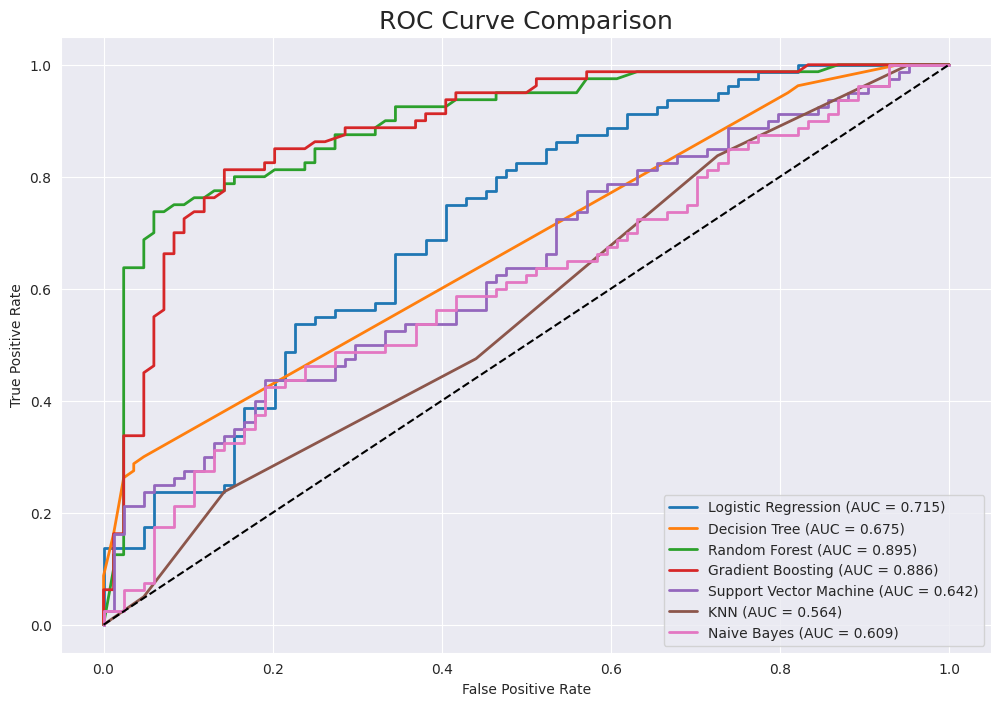

FINAL MODEL COMPARISON
                    Model  Accuracy   ROC_AUC
3       Gradient Boosting  0.829268  0.886235
2           Random Forest  0.786585  0.895312
0     Logistic Regression  0.640244  0.714583
1           Decision Tree  0.634146  0.674628
6             Naive Bayes  0.603659  0.609077
4  Support Vector Machine  0.597561  0.641518
5                     KNN  0.518293  0.563839


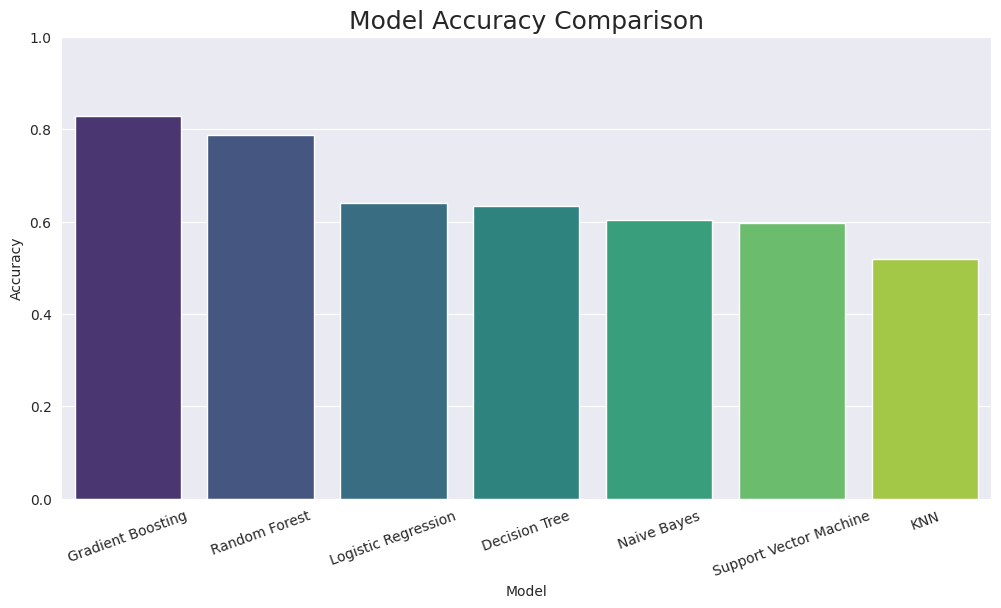

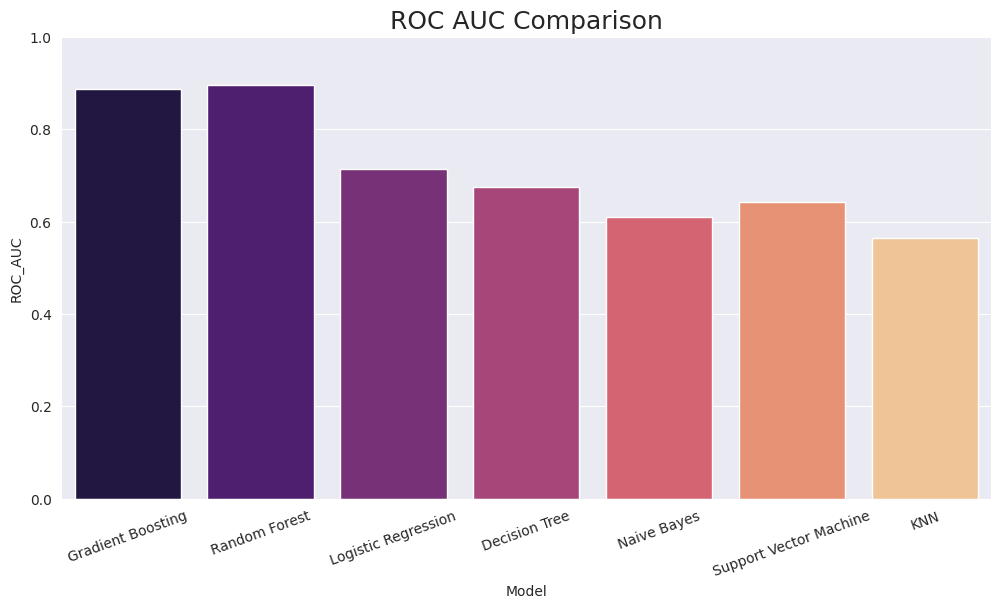

TOP FEATURE IMPORTANCE
         Feature  Importance
5   mean_feature    0.246379
1   country_name    0.243225
4    sum_feature    0.225803
0   country_code    0.205456
2           year    0.079137
3  source_engine    0.000000


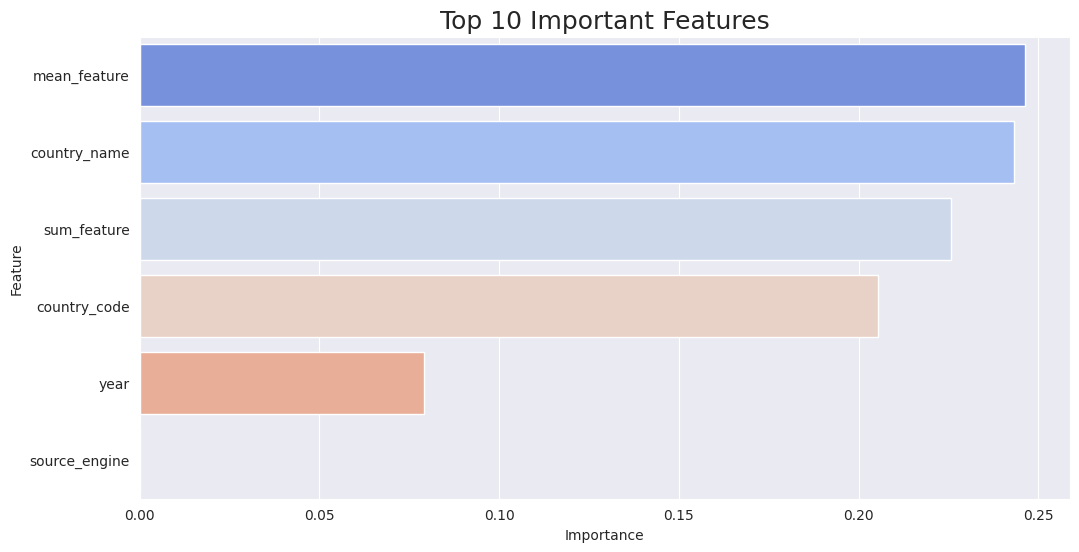

PROJECT COMPLETED SUCCESSFULLY


In [5]:
# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

# ML Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score



df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("="*60)
print("COLUMN NAMES")
print("="*60)

print(df.columns.tolist())


print("="*60)
print("DATASET SHAPE")
print("="*60)

print(df.shape)

print("="*60)
print("FIRST 5 ROWS")
print("="*60)

print(df.head())


# Numeric columns
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    
    df[col] = df[col].fillna(df[col].median())

# Categorical columns
categorical_cols = df.select_dtypes(exclude=np.number).columns

for col in categorical_cols:
    
    df[col] = df[col].fillna(df[col].mode()[0])

print("="*60)
print("MISSING VALUES HANDLED")
print("="*60)


median_value = df['remittance_cost_pct'].median()

df['target'] = np.where(
    df['remittance_cost_pct'] > median_value,
    1,
    0
)

print("="*60)
print("TARGET VALUE COUNTS")
print("="*60)

print(df['target'].value_counts())

drop_cols = [
    'remittance_cost_pct'
]

X = df.drop(columns=drop_cols + ['target'])

y = df['target']

# ============================================================
# 8. LABEL ENCODING
# ============================================================

label_encoders = {}

categorical_cols = X.select_dtypes(include='object').columns

for col in categorical_cols:
    
    le = LabelEncoder()
    
    X[col] = le.fit_transform(X[col].astype(str))
    
    label_encoders[col] = le

print("="*60)
print("LABEL ENCODING COMPLETED")
print("="*60)

# ============================================================
# 9. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("="*60)
print("TRAIN TEST SPLIT")
print("="*60)

print("X_train Shape :", X_train.shape)
print("X_test Shape  :", X_test.shape)

# ============================================================
# 10. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

# IMPORTANT:
# transform only on test
# no fit on test data

X_test_scaled = scaler.transform(X_test)

# ============================================================
# 11. MACHINE LEARNING MODELS
# ============================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True,
        random_state=42
    ),

    "KNN": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()
}

# ============================================================
# 12. TRAINING & EVALUATION
# ============================================================

results = []

plt.figure(figsize=(12,8))

for name, model in models.items():

    print("="*70)
    print(f"MODEL : {name}")
    print("="*70)

    # =====================================
    # TRAIN MODEL
    # =====================================

    model.fit(X_train_scaled, y_train)

    # =====================================
    # PREDICTIONS
    # =====================================

    y_pred = model.predict(X_test_scaled)

    # =====================================
    # ACCURACY
    # =====================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"Accuracy Score : {accuracy:.4f}")

    # =====================================
    # CLASSIFICATION REPORT
    # =====================================

    print("\nClassification Report\n")

    print(
        classification_report(
            y_test,
            y_pred
        )
    )

    # =====================================
    # CONFUSION MATRIX
    # =====================================

    cm = confusion_matrix(y_test, y_pred)

    print("\nConfusion Matrix\n")

    print(cm)

    # =====================================
    # ROC CURVE
    # =====================================

    y_prob = model.predict_proba(X_test_scaled)[:,1]

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    roc_auc = auc(fpr, tpr)

    print(f"\nROC AUC Score : {roc_auc:.4f}")

    # Store results
    results.append([name, accuracy, roc_auc])

    # Plot ROC
    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{name} (AUC = {roc_auc:.3f})"
    )

# ============================================================
# 13. FINAL ROC CURVE
# ============================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title(
    "ROC Curve Comparison",
    fontsize=18
)

plt.legend()

plt.show()

# ============================================================
# 14. RESULTS TABLE
# ============================================================

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'Accuracy',
        'ROC_AUC'
    ]
)

results_df = results_df.sort_values(
    by='Accuracy',
    ascending=False
)

print("="*70)
print("FINAL MODEL COMPARISON")
print("="*70)

print(results_df)

# ============================================================
# 15. VISUALIZE ACCURACY
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='Accuracy',
    palette='viridis'
)

plt.xticks(rotation=20)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18
)

plt.ylim(0,1)

plt.show()

# ============================================================
# 16. VISUALIZE ROC AUC
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x='Model',
    y='ROC_AUC',
    palette='magma'
)

plt.xticks(rotation=20)

plt.title(
    "ROC AUC Comparison",
    fontsize=18
)

plt.ylim(0,1)

plt.show()

# ============================================================
# 17. FEATURE IMPORTANCE
# ============================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

importance = pd.DataFrame({

    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print("="*70)
print("TOP FEATURE IMPORTANCE")
print("="*70)

print(importance.head(10))

# ============================================================
# 18. FEATURE IMPORTANCE PLOT
# ============================================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=importance.head(10),
    x='Importance',
    y='Feature',
    palette='coolwarm'
)

plt.title(
    "Top 10 Important Features",
    fontsize=18
)

plt.show()

# ============================================================
# 19. SAVE RESULTS
# ============================================================

results_df.to_csv(
    "ml_model_results.csv",
    index=False
)

importance.to_csv(
    "feature_importance.csv",
    index=False
)

print("="*70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("="*70)

## Thank you...pls upvote!!!!!!!!!